## Self Attention Code

In [2]:
sentence = 'Life is short, eat dessert first'

In [3]:
# dc is word dicionary, where each word is assigned an index 

dc = {s:i for i,s in enumerate(sorted(sentence.replace(',', '').split()))}
print(dc)

{'Life': 0, 'dessert': 1, 'eat': 2, 'first': 3, 'is': 4, 'short': 5}


In [4]:
import torch


In [5]:
#  we use this dictionary to assign an integer index to each word
sentence_int  = torch.tensor([dc[s] for s in sentence.replace(',', '').split()])
sentence_int

tensor([0, 4, 5, 2, 1, 3])

In [6]:
torch.manual_seed(123)
num_of_words = len(dc)
embedding_size = 4
embed_layer = torch.nn.Embedding(num_of_words, embedding_size)

In [7]:
embedding_of_words  = embed_layer(sentence_int).detach()

In [8]:

embedding_of_words

tensor([[ 0.3374, -0.1778, -0.3035, -0.5880],
        [-0.7849, -1.4096, -0.4076,  0.7953],
        [ 0.9985,  0.2212,  1.8319, -0.3378],
        [-0.1606, -0.4015,  0.6957, -1.8061],
        [ 0.3486,  0.6603, -0.2196, -0.3792],
        [ 1.8960, -0.1750,  1.3689, -1.6033]])

In [9]:
# Add positional encoding to the word embeddings
## Why ?
## Unlike RNNs, Transformers do not have a built-in notion of sequence order. (as we proces all words in parallel)
## Positional encoding provides a way to inject information about the position of each word in the sequence
import math

def positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

pos_embed = positional_encoding(embedding_of_words.shape[0], embedding_of_words.shape[1])



In [10]:
pos_embed

tensor([[ 0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0100,  0.9999],
        [ 0.9093, -0.4161,  0.0200,  0.9998],
        [ 0.1411, -0.9900,  0.0300,  0.9996],
        [-0.7568, -0.6536,  0.0400,  0.9992],
        [-0.9589,  0.2837,  0.0500,  0.9988]])

## Position embeding:

**NOTE: Positional embedding is directly proportional to position of the token but inversally to index of the the dimension of that token**

**Why ?**

* **First let's understand w.r.t Position: We want different position of the token in a sentence to have a different positional embedding**
* **Second w.r.t index i, this is linekd to higher frequency for lower index and lower frequency for higher index. Logic is explained in next below sections** 

** Why the positional embedding formula is directly proportional to the position of the token in a sentence

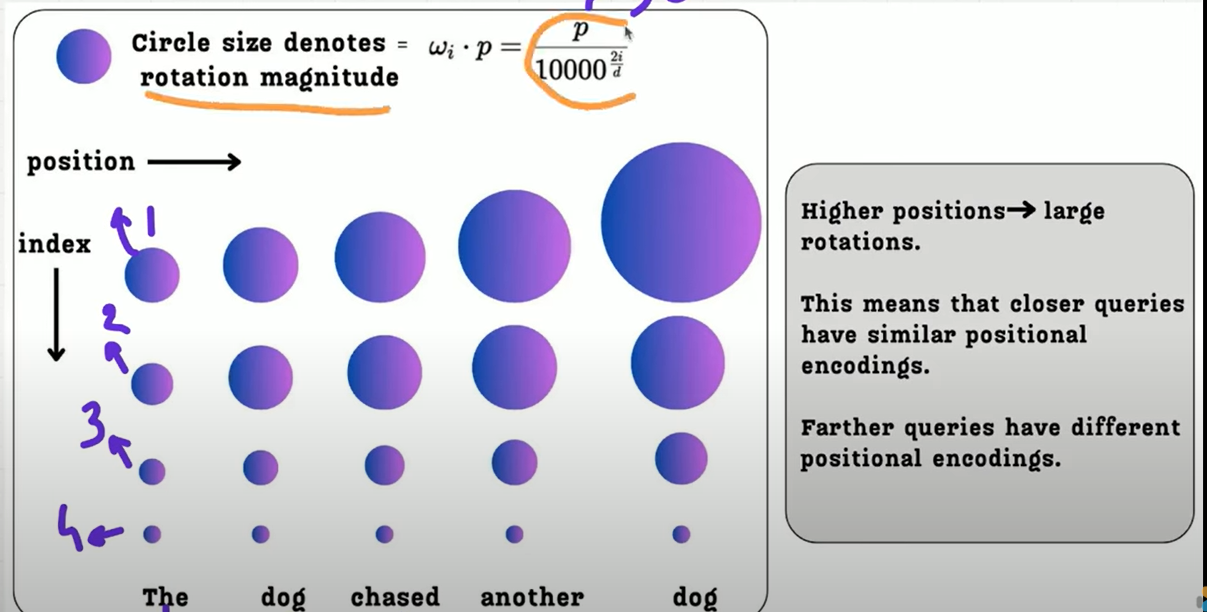


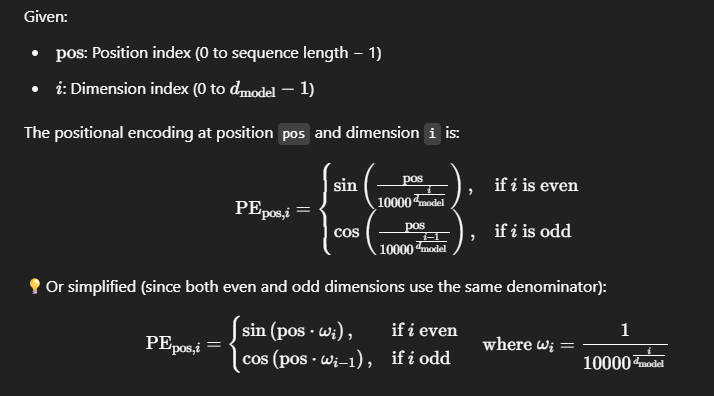

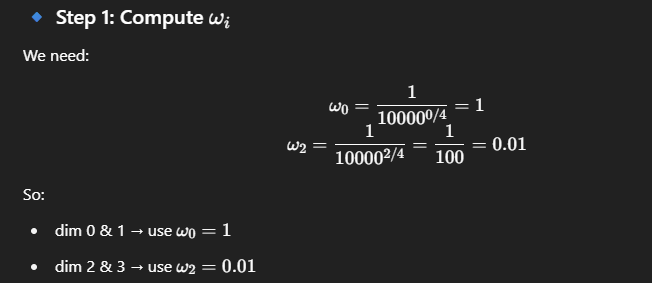

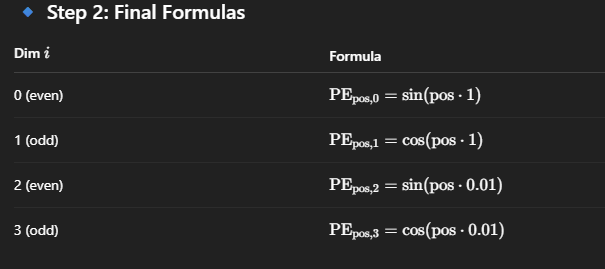

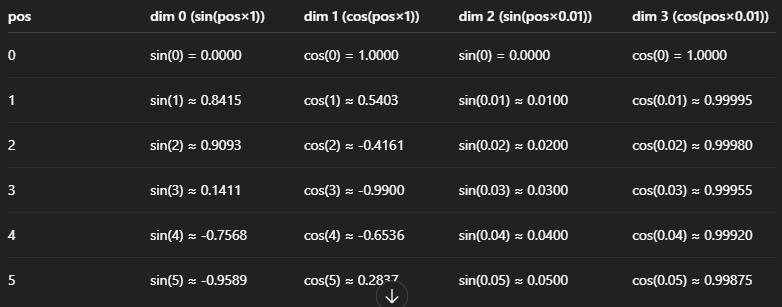




#### High Frequency for lower Dimensions of the embddding


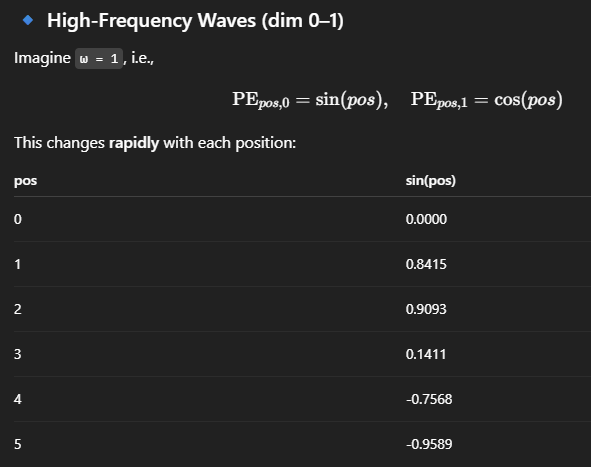

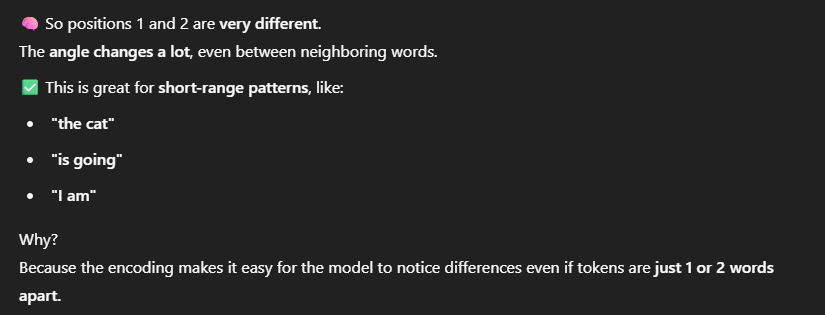

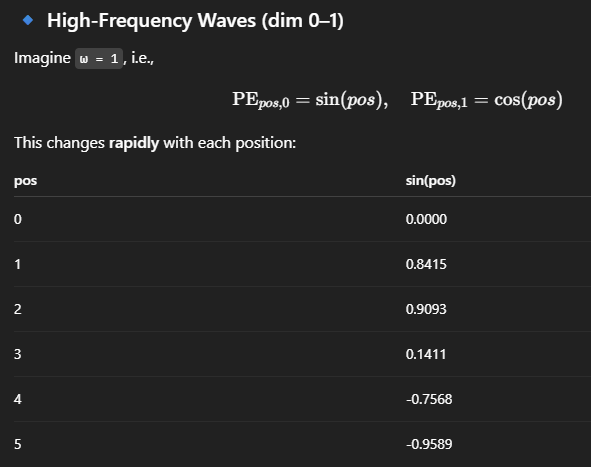

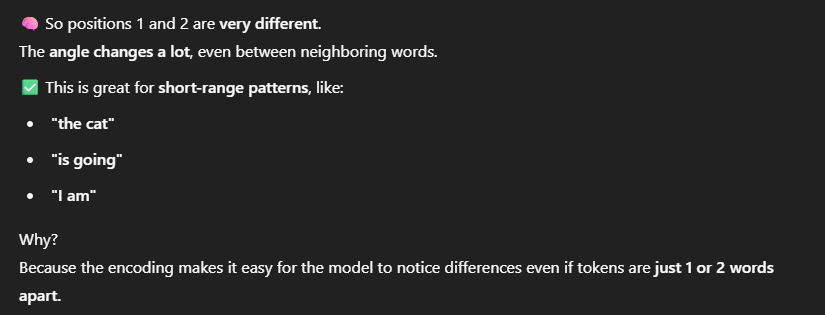



#### Low Frequency for higher Dimensions of the embddding


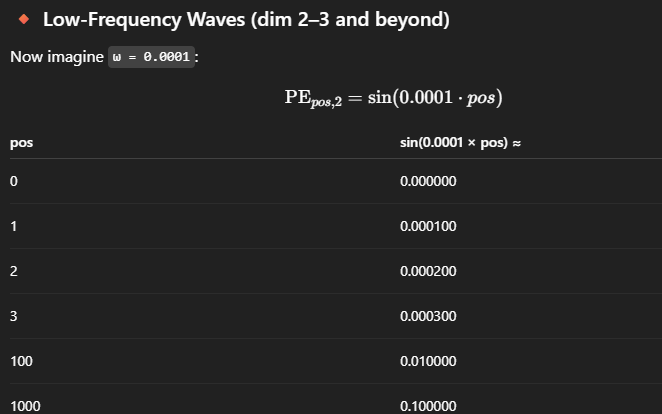

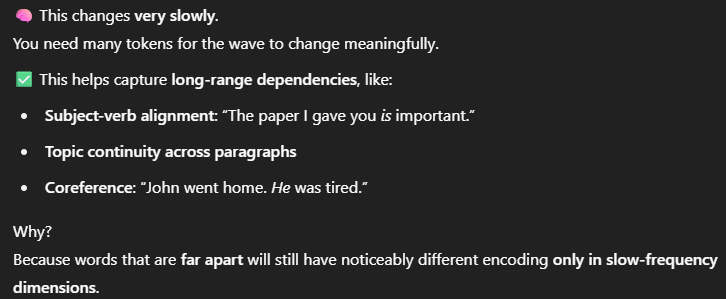

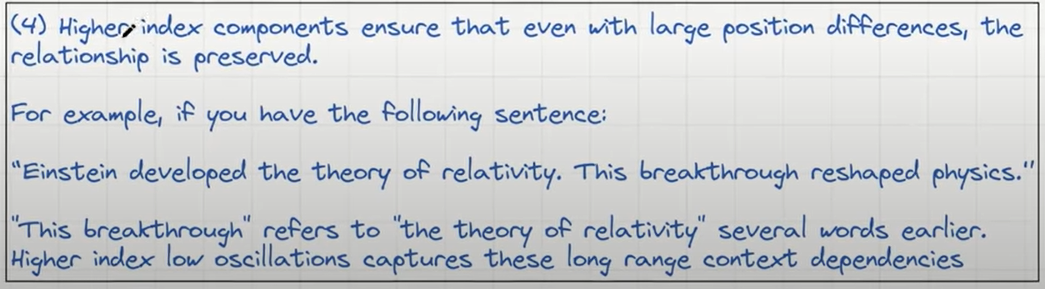

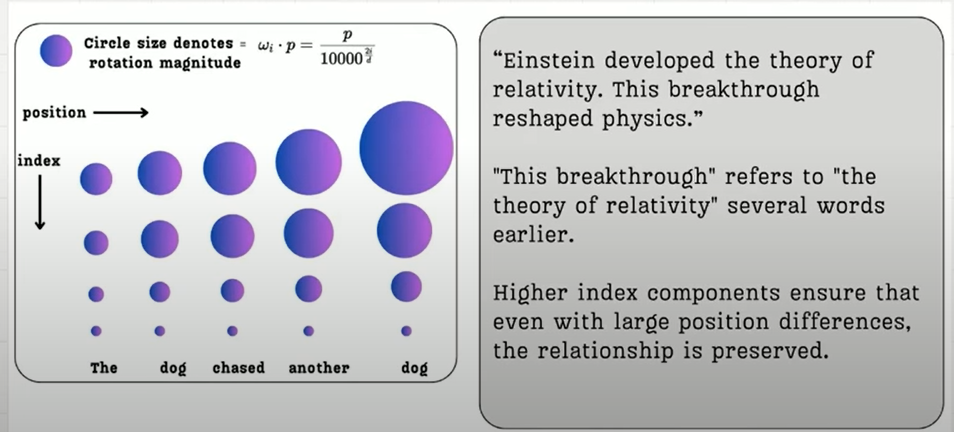



#### WHY COMBINE BOTH:


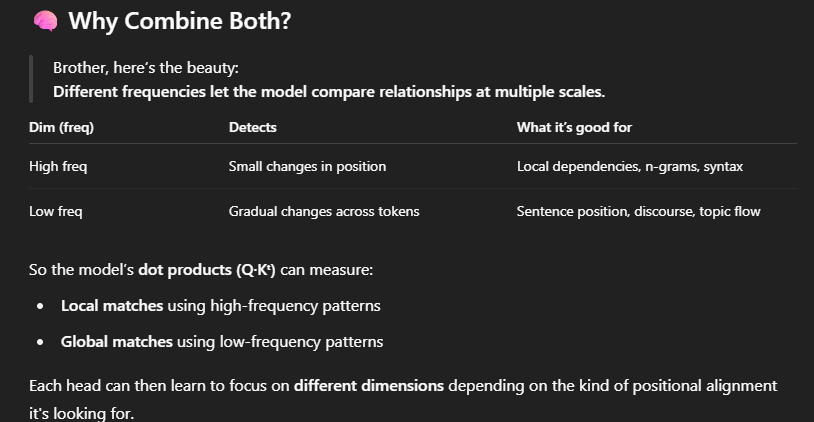

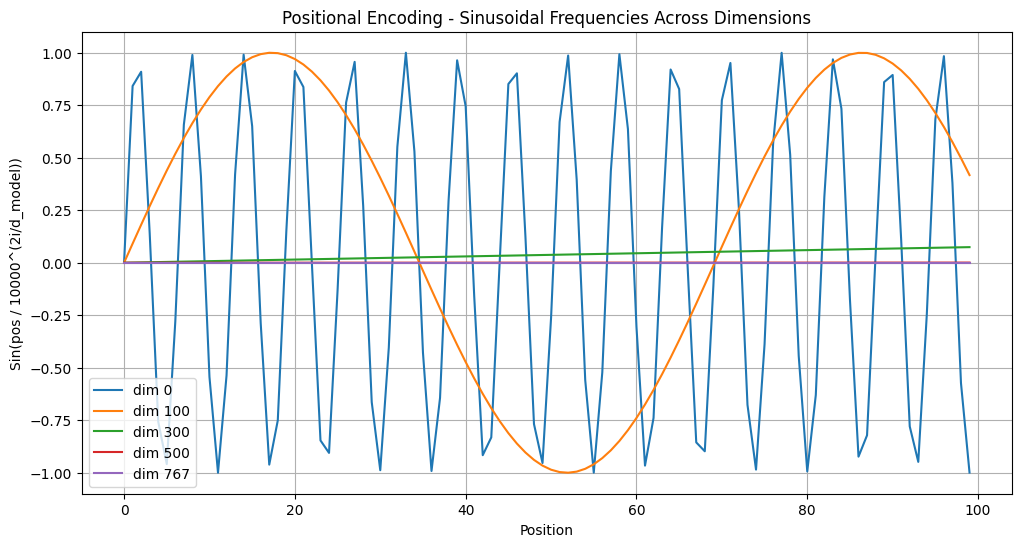

In [39]:
import numpy as np
import matplotlib.pyplot as plt

positions = np.arange(0, 100)
d_model = 768

plt.figure(figsize=(12, 6))
for i in [0, 100, 300, 500, 767]:
    angle = positions / np.power(10000, (2*i/d_model))
    plt.plot(positions, np.sin(angle), label=f'dim {i}')

plt.legend()
plt.title("Positional Encoding - Sinusoidal Frequencies Across Dimensions")
plt.xlabel("Position")
plt.ylabel("Sin(pos / 10000^(2i/d_model))")
plt.grid(True)
plt.show()


In [11]:
embedding_with_pos = embedding_of_words + pos_embed

In [12]:
embedding_with_pos.shape

torch.Size([6, 4])

In [13]:
embedding_of_words

tensor([[ 0.3374, -0.1778, -0.3035, -0.5880],
        [-0.7849, -1.4096, -0.4076,  0.7953],
        [ 0.9985,  0.2212,  1.8319, -0.3378],
        [-0.1606, -0.4015,  0.6957, -1.8061],
        [ 0.3486,  0.6603, -0.2196, -0.3792],
        [ 1.8960, -0.1750,  1.3689, -1.6033]])

In [14]:
d_q, d_k, d_v = embedding_size*2, embedding_size*2, embedding_size*2
# d_k is same as d_v
## Why ? Since we are computing the dot-product between the query and key vectors, these two vectors have to contain the same number of elements
## d_v can be different from d_q and d_k, since the value vector is used to compute the final output of the attention mechanism, which can have a different dimensionality.
## but for simiplicity, we will keep all 3 same here
W_q = torch.nn.Linear(embedding_size, d_k, bias=False)
W_k = torch.nn.Linear(embedding_size, d_q, bias=False)
W_v = torch.nn.Linear(embedding_size, d_v, bias=False)

In [15]:
W_q, W_k, W_v

(Linear(in_features=4, out_features=8, bias=False),
 Linear(in_features=4, out_features=8, bias=False),
 Linear(in_features=4, out_features=8, bias=False))

In [16]:
embedding_with_pos[0].shape

torch.Size([4])

In [17]:
W_q(embedding_with_pos).shape
## embedding_of_words.matmul(W_q.weight.T).shape

torch.Size([6, 8])

In [21]:
q_2 = W_q(embedding_with_pos[2])

In [22]:
q = W_q(embedding_with_pos)
k = W_k(embedding_with_pos)
v = W_v(embedding_with_pos)

In [23]:
q.shape, k.shape, v.shape, q_2.shape

(torch.Size([6, 8]), torch.Size([6, 8]), torch.Size([6, 8]), torch.Size([8]))

In [27]:
un_normalised_attn_weights_2 = q_2.matmul(k.T)/(torch.sqrt(torch.tensor(d_k, dtype=torch.float32)))
un_normalised_attn_weights_2


tensor([-0.3778, -0.2729, -0.0585,  0.6170, -0.1053,  0.2172],
       grad_fn=<DivBackward0>)

In [28]:
un_normalised_attn_weights = q.matmul(k.T)/(torch.sqrt(torch.tensor(d_k, dtype=torch.float32)))
un_normalised_attn_weights

# Why divide by sqrt(d_k) ?
### 1.  The dot product 𝑄⋅𝐾(𝑇) grows with vector dimensionality. So, The division by sqrt(d_k) is a scaling factor that helps to 
#       prevent the dot product values from becoming too large, which can lead to numerical instability and saturation of the softmax function.
### 2.  When the dot product values are large, softmax outputs become very sharp → almost one-hot.That means the model starts focusing too much 
#       on one token and ignoring the rest.This hurts gradient flow during training and causes learning to become unstable. So, By dividing by 
#       sqrt(d_k) we reduce the magnitude of dot products.This ensures moderate values before softmax, giving smoother attention
#       distributions and better training stability.

tensor([[ 7.5000e-02,  3.0940e-02,  6.7932e-02, -1.0238e-01, -2.5734e-03,
         -6.9236e-04],
        [-5.6276e-01, -4.4616e-01,  1.9307e-01,  9.6227e-01, -1.8540e-01,
          5.1137e-01],
        [-3.7782e-01, -2.7294e-01, -5.8471e-02,  6.1703e-01, -1.0530e-01,
          2.1720e-01],
        [-1.1238e-01, -4.6654e-02, -2.1180e-01,  1.2239e-01,  3.1056e-02,
         -6.0141e-02],
        [-1.4563e-01, -1.1053e-01,  1.6831e-01,  2.8545e-01, -8.0530e-02,
          1.9479e-01],
        [ 3.0003e-02,  5.0441e-02, -1.2926e-01, -6.9241e-02,  2.3128e-02,
         -1.1235e-01]], grad_fn=<DivBackward0>)

In [29]:
normalised_attn_weights = un_normalised_attn_weights.softmax(dim=-1)
normalised_attn_weights

tensor([[0.1773, 0.1697, 0.1761, 0.1485, 0.1641, 0.1644],
        [0.0756, 0.0849, 0.1609, 0.3472, 0.1102, 0.2212],
        [0.1073, 0.1192, 0.1477, 0.2902, 0.1409, 0.1946],
        [0.1551, 0.1657, 0.1405, 0.1962, 0.1791, 0.1635],
        [0.1348, 0.1397, 0.1846, 0.2075, 0.1439, 0.1895],
        [0.1773, 0.1810, 0.1512, 0.1606, 0.1761, 0.1538]],
       grad_fn=<SoftmaxBackward0>)

In [30]:
normalised_attn_weights_2 = un_normalised_attn_weights_2.softmax(dim=-1)
normalised_attn_weights_2

tensor([0.1073, 0.1192, 0.1477, 0.2902, 0.1409, 0.1946],
       grad_fn=<SoftmaxBackward0>)

In [31]:
normalised_attn_weights.shape, v.shape, normalised_attn_weights_2.shape

(torch.Size([6, 6]), torch.Size([6, 8]), torch.Size([6]))

In [32]:
v

tensor([[ 0.0315, -0.1315,  0.0993,  0.0434, -0.1446, -0.0300,  0.4877, -0.4090],
        [ 0.9068, -0.5853,  0.1946,  0.6287, -0.7491,  0.5067, -0.0195, -0.2241],
        [ 0.1730,  0.9603,  0.3783, -0.1478,  0.4514,  1.4930, -0.0979, -0.3672],
        [-0.1594,  0.4624, -0.0508, -0.2957,  0.2882,  0.3382, -0.8055,  0.7044],
        [ 0.3222, -0.3237, -0.0536,  0.3916, -0.1580, -0.1138,  0.0634, -0.1889],
        [-0.3452,  0.8902,  0.0776, -0.3725,  0.7124,  0.6127, -0.1924, -0.0086]],
       grad_fn=<MmBackward0>)

In [23]:
result = sum([0.1633, 0.1449, 0.2065, 0.1484, 0.1500, 0.1869][i] * [0.3946, 0.3135, 0.6157, -0.6482, 0.1899, 0.1153][i] for i in range(6))
result


0.19084807

In [24]:
result = sum([0.1633, 0.1449, 0.2065, 0.1484, 0.1500, 0.1869][i] * [ 0.1818,  0.6372, -1.2404, -0.6065,  0.3861, -1.0936][i] for i in range(6))
result


-0.37060782

In [33]:
normalised_attn_weights@v

tensor([[ 0.1623,  0.2083,  0.1136,  0.0474,  0.0607,  0.4758, -0.0749, -0.1030],
        [ 0.0110,  0.4167,  0.0785, -0.1090,  0.2384,  0.5214, -0.2958,  0.1129],
        [ 0.0690,  0.3198,  0.0825, -0.0454,  0.1619,  0.4790, -0.2267,  0.0513],
        [ 0.1494,  0.1958,  0.0939,  0.0413,  0.0616,  0.4351, -0.1194, -0.0492],
        [ 0.1107,  0.2959,  0.1068, -0.0092,  0.1313,  0.5122, -0.1495, -0.0369],
        [ 0.1739,  0.1701,  0.1044,  0.0633,  0.0351,  0.4406, -0.0796, -0.0901]],
       grad_fn=<MmBackward0>)

In [34]:
normalised_attn_weights[0]@v 
# --- This is context vector for token 1

tensor([ 0.1623,  0.2083,  0.1136,  0.0474,  0.0607,  0.4758, -0.0749, -0.1030],
       grad_fn=<SqueezeBackward4>)

In [35]:
normalised_attn_weights_2@v ## This code is multiplying token 2's attention with all the token's value vector
# --- This is context vector for token 2

tensor([ 0.0690,  0.3198,  0.0825, -0.0454,  0.1619,  0.4790, -0.2267,  0.0513],
       grad_fn=<SqueezeBackward4>)

In [27]:
context_vector = normalised_attn_weights.matmul(v)
context_vector.shape

torch.Size([6, 8])

In [28]:
context_vector

tensor([[ 0.1623,  0.2083,  0.1136,  0.0474,  0.0607,  0.4758, -0.0749, -0.1030],
        [ 0.0110,  0.4167,  0.0785, -0.1090,  0.2384,  0.5214, -0.2958,  0.1129],
        [ 0.0690,  0.3198,  0.0825, -0.0454,  0.1619,  0.4790, -0.2267,  0.0513],
        [ 0.1494,  0.1958,  0.0939,  0.0413,  0.0616,  0.4351, -0.1194, -0.0492],
        [ 0.1107,  0.2959,  0.1068, -0.0092,  0.1313,  0.5122, -0.1495, -0.0369],
        [ 0.1739,  0.1701,  0.1044,  0.0633,  0.0351,  0.4406, -0.0796, -0.0901]],
       grad_fn=<MmBackward0>)

In [29]:
embedding_of_words[0]

tensor([ 0.3374, -0.1778, -0.3035, -0.5880])

In [30]:
embedding_with_pos[0]

tensor([ 0.3374,  0.8222, -0.3035,  0.4120])

In [31]:
context_vector[0]

tensor([ 0.1623,  0.2083,  0.1136,  0.0474,  0.0607,  0.4758, -0.0749, -0.1030],
       grad_fn=<SelectBackward0>)

In [32]:
W_o = torch.nn.Linear(d_v, embedding_size, bias=False)
W_o
## This is needed to project the context vector back to the original embedding size since we used different d_k, d_v, d_q than the embedding size

Linear(in_features=8, out_features=4, bias=False)

In [33]:
output_vector = W_o(context_vector)
output_vector.shape

torch.Size([6, 4])

In [34]:
add_normalise_context_vector = embedding_with_pos+output_vector

In [35]:
add_normalise_context_vector.shape

torch.Size([6, 4])

In [36]:

# It is actually just a linear layer that gets applied to each position(or word)
class PositionWiseFeedForward(torch.nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = torch.nn.Linear(d_model, d_ff)
        self.fc2 = torch.nn.Linear(d_ff, d_model)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [37]:
pff = PositionWiseFeedForward(embedding_size, embedding_size*2)

In [38]:
ff_add_normalise_context_vector = pff(add_normalise_context_vector)#.shape

In [39]:
add_ff_add_normalise_context_vector = ff_add_normalise_context_vector + add_normalise_context_vector

In [40]:
add_ff_add_normalise_context_vector.shape

torch.Size([6, 4])

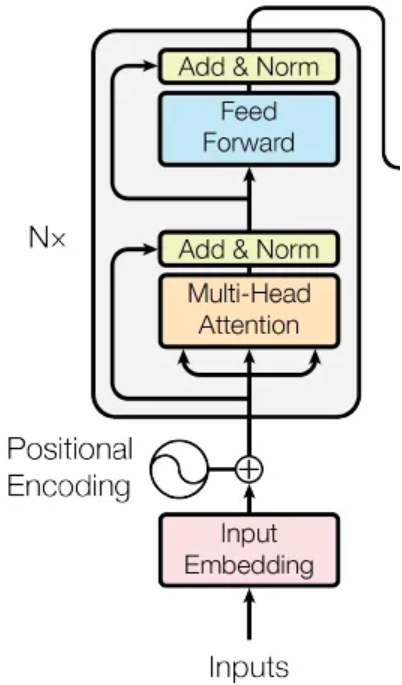

## Multi-Head attention

* Why multi-head attention?
    * Problem with single head: If the sentence has multiple semantic patterns or linguistic structures, a single head can only focus on one at a time.
    * Solution: Multi-head attention allows the model to attend to different parts of the sequence in different ways — capturing different types of relationships and patterns simultaneously.
    * Each head learns to specialize:
        * One head may focus on local dependencies (e.g., next word)
        * Another may capture long-range dependencies
        * One might learn syntactic relationships (subject-verb)
        * Another might capture semantic meaning (actor vs action)


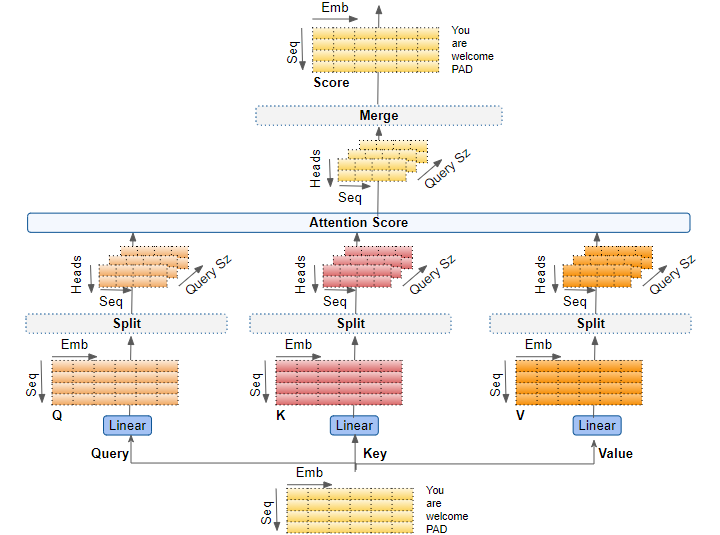

In [41]:
import math
import torch.nn as nn

In [54]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_size, num_heads, q_k_v_projection):
        super().__init__()
        assert embed_size % num_heads == 0, "embed_size must be divisible by num_heads"
        self.embed_size = embed_size
        self.num_heads = num_heads
        self.head_dim = q_k_v_projection // num_heads #### This means that q,,k,v values will be divided equally into num_heads
       
        # joint projection to Q, K, V of full dimension
        self.W_q = nn.Linear(embed_size, q_k_v_projection, bias=False)
        self.W_k = nn.Linear(embed_size, q_k_v_projection, bias=False)
        self.W_v = nn.Linear(embed_size, q_k_v_projection, bias=False)
        # final output projection
        self.out_proj = nn.Linear(q_k_v_projection, embed_size)

    def forward(self, x):
        # x: seq_len × embed_size
        seq_len, _ = x.shape

        # 1) linear projections
        self.q = self.W_q(x)  # seq_len × embed_size
        self.k = self.W_k(x)
        self.v = self.W_v(x)

        # 2) reshape into (seq_len × num_heads × head_dim)
        self.q = self.q.view(seq_len, self.num_heads, self.head_dim)
        self.k = self.k.view(seq_len, self.num_heads, self.head_dim)
        self.v = self.v.view(seq_len, self.num_heads, self.head_dim)

        # 3) scaled dot-product per head
        heads = []
        for h in range(self.num_heads):
            qi = self.q[:, h, :]                 # seq_len × head_dim
            ki = self.k[:, h, :]
            vi = self.v[:, h, :]

            scores = qi @ ki.T             # seq_len × seq_len
            scores = scores / math.sqrt(self.head_dim)
            weights = scores.softmax(dim=-1)

            head = weights @ vi            # seq_len × head_dim
            heads.append(head)

        # 4) concatenate all heads: seq_len × (num_heads * head_dim)
        concat = torch.cat(heads, dim=-1)

        # 5) final linear projection
        out = self.out_proj(concat)       # seq_len × embed_size
        return out

In [55]:
num_heads = 4
mha = MultiHeadSelfAttention(embedding_size, num_heads, embedding_size*2)

In [56]:
embedding_with_pos.shape

torch.Size([6, 4])

In [57]:
multi_head_output = mha(embedding_with_pos)
multi_head_output

tensor([[ 0.1457, -0.3164, -0.0242,  0.1066],
        [ 0.2262, -0.3068, -0.0607,  0.0727],
        [ 0.1189, -0.2974,  0.0064,  0.1891],
        [ 0.1251, -0.2946, -0.0453,  0.1559],
        [ 0.1717, -0.3112, -0.0567,  0.0900],
        [ 0.0819, -0.2992, -0.0082,  0.1867]], grad_fn=<AddmmBackward0>)

In [58]:
mha.q.shape

torch.Size([6, 4, 2])

In [ ]:
## But for loop on number of heads is not efficient, so we can do it in a vectorised way

In [1]:
import torch
import torch.nn.functional as F
import math
import torch.nn as nn


In [76]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_size, num_heads, q_k_v_projection):
        super().__init__()
        assert embed_size % num_heads == 0, "embed_size must be divisible by num_heads"
        self.embed_size = embed_size
        self.num_heads = num_heads
        self.head_dim = q_k_v_projection // num_heads #### This means that q,,k,v values will be divided equally into num_heads
       
        # joint projection to Q, K, V of full dimension
        self.W_q = nn.Linear(embed_size, q_k_v_projection, bias=False)
        self.W_k = nn.Linear(embed_size, q_k_v_projection, bias=False)
        self.W_v = nn.Linear(embed_size, q_k_v_projection, bias=False)
        # final output projection
        self.out_proj = nn.Linear(q_k_v_projection, embed_size)
        self.q_k_v_projection = q_k_v_projection

    def forward(self, x):
        # x: seq_len × embed_size
        seq_len, _ = x.shape

        # 1) linear projections
        self.q = self.W_q(x)  # seq_len × embed_size
        self.k = self.W_k(x)
        self.v = self.W_v(x)

        # 2) reshape into (seq_len × num_heads × head_dim)
        self.q = self.q.view(seq_len, self.num_heads, self.head_dim)
        self.k = self.k.view(seq_len, self.num_heads, self.head_dim)
        self.v = self.v.view(seq_len, self.num_heads, self.head_dim)

        # 3) scaled dot-product attention in parallel
        # scores: [num_heads, seq_len, seq_len]
        self.scores = torch.matmul(self.q, self.k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        self.weights = F.softmax(self.scores, dim=-1)    # [num_heads, seq_len, seq_len]
        self.context = torch.matmul(self.weights, self.v)     # [num_heads, seq_len, head_dim]

        # 4) concatenate all heads
        seq_length, _,_=self.context.size()
        concat =self.context.transpose(1,2).contiguous().view(seq_length, self.q_k_v_projection)
        
        # 5) final linear projection
        out = self.out_proj(concat)       # seq_len × embed_size
        return out

In [77]:
num_heads = 4
mha = MultiHeadSelfAttention(embedding_size, num_heads, embedding_size*2)

In [78]:
multi_head_output = mha(embedding_with_pos)
multi_head_output

tensor([[-0.1843, -0.2675,  0.0341,  0.1259],
        [-0.1925, -0.1908,  0.0401,  0.3472],
        [ 0.0540, -0.1780,  0.1780,  0.4541],
        [-0.1822, -0.3214, -0.0701,  0.3110],
        [-0.1896, -0.3031, -0.0007,  0.1858],
        [-0.0974, -0.2552,  0.0603,  0.3499]], grad_fn=<AddmmBackward0>)

In [81]:
multi_head_output.shape

torch.Size([6, 4])

## Masking concept (one of the core ideas behind BERT training)


* Masking is the technique of hiding certain parts of the input from the model during training or inference so that it does not attend to them.
    * A: Attention Mask:
        * Padding Mask: In NLP tasks, sequences are padded to the same length. Padding tokens (e.g. [PAD]) should not influence the output.
        * Look-Ahead Mask (Causal Mask): In sequence generation (e.g., GPT), the model should only look at current and past tokens, not future ones.
    * B: Masked Language Modeling (MLM) Mask: In models like BERT, we intentionally mask some tokens (e.g., [MASK]) and train the model to predict them using the surrounding context
* Benefits of Masking
    * Improves language understanding: MLM helps BERT learn bidirectional context
    * Prevents information leakage: e.g., in GPT, can't "cheat" by seeing the next word

* MLM: In MLM, we mask (hide) some tokens from a sentence and train the model to predict the original tokens based on both left and right context
* MLM Step by Step:

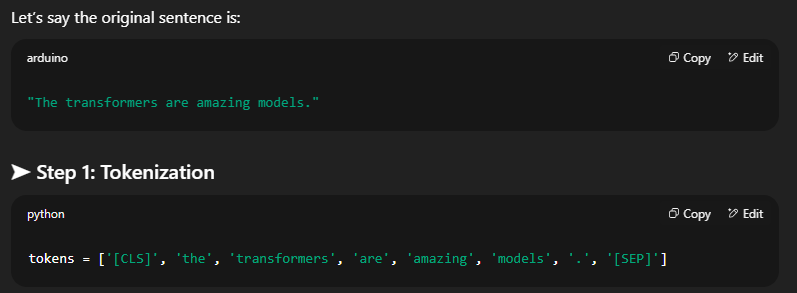
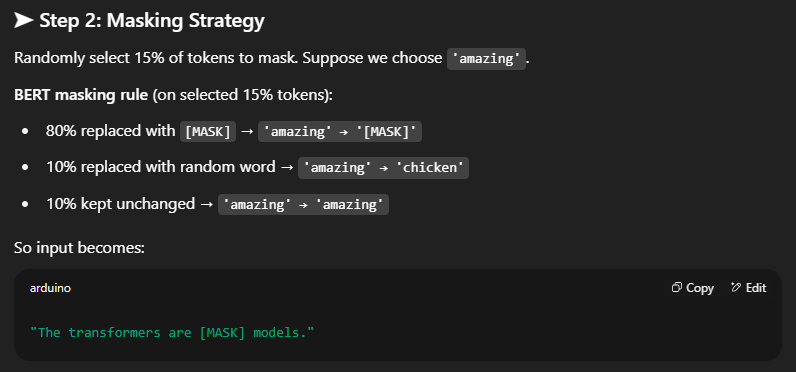
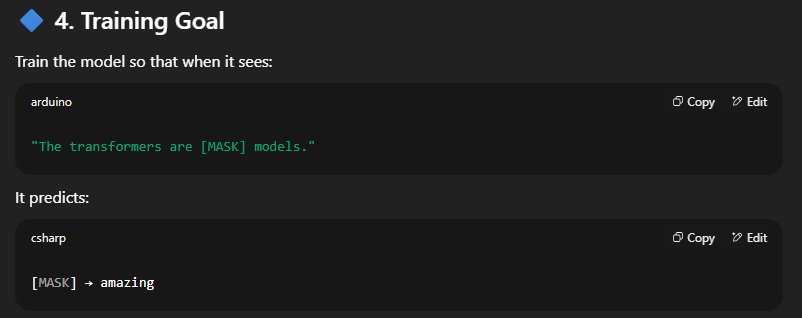

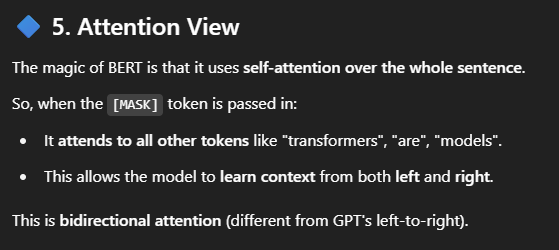

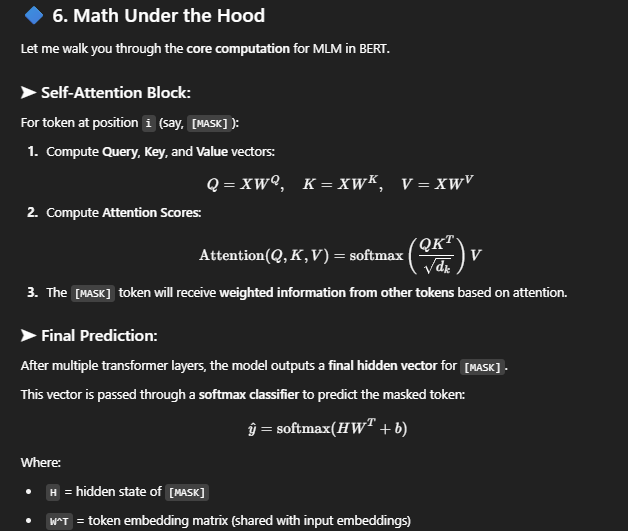

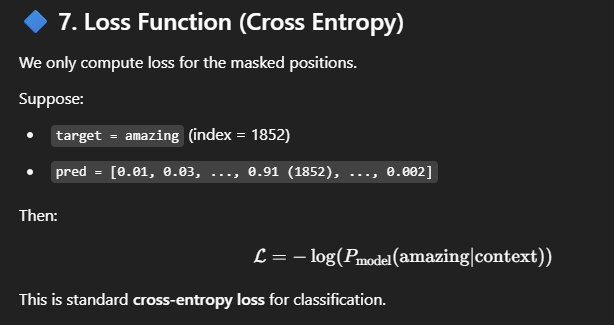

* Limitation of MLM:
    * Can't be used for text generation

* Summary:

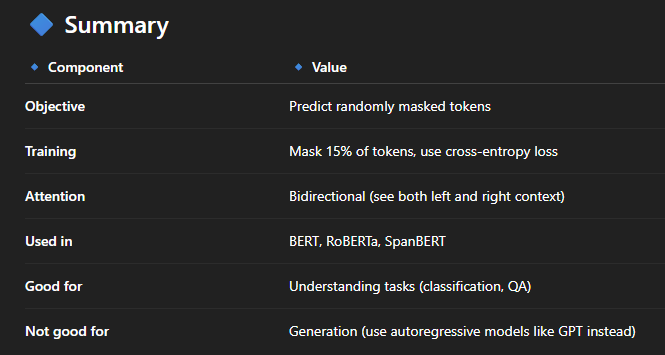

### If [mask] tokens have same embedding, then how is it learning to predict different words in sentence ?



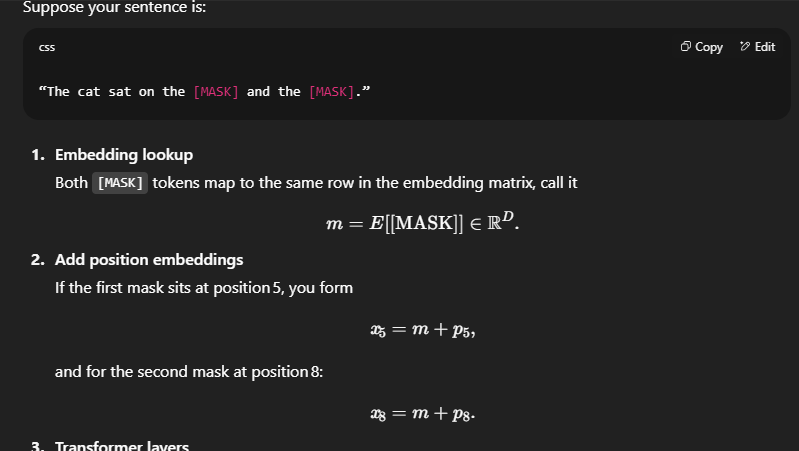

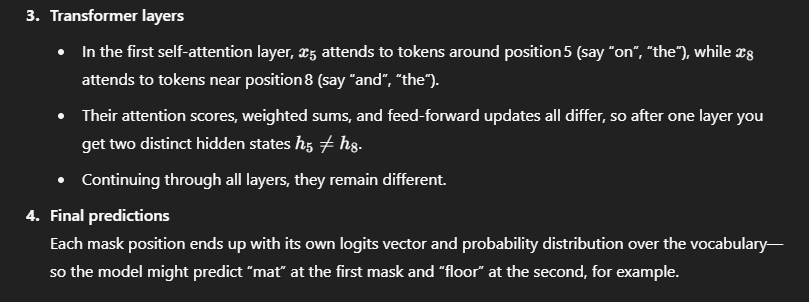

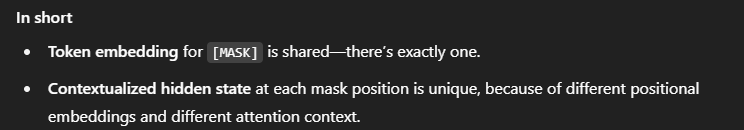

## Attention Mask vs [MLM] masking



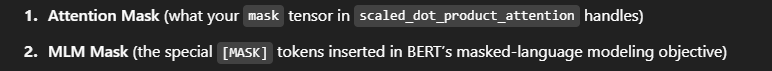

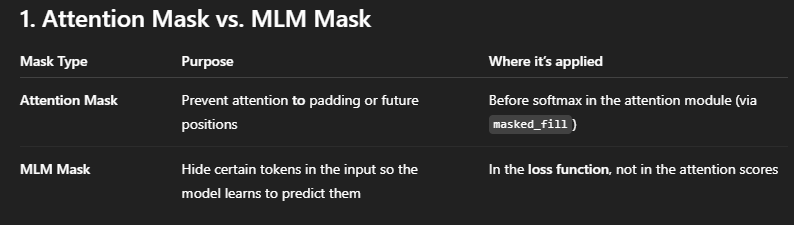

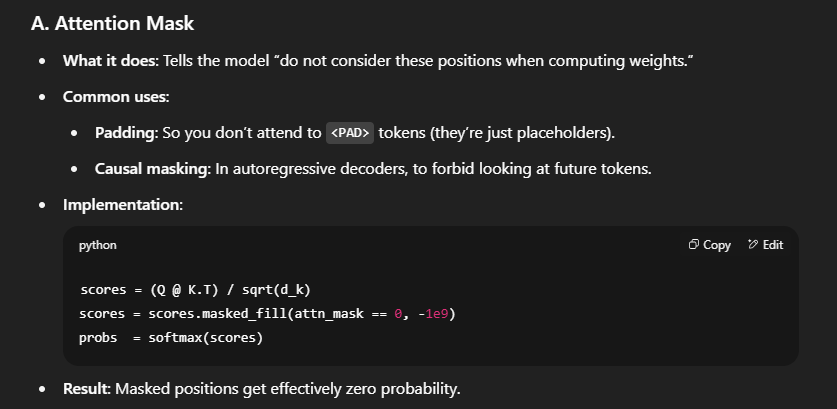

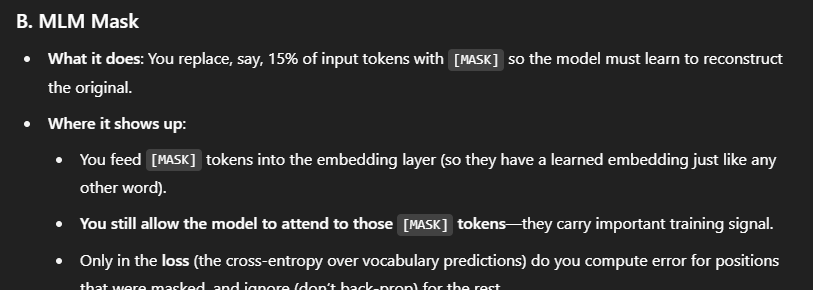

In [37]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 6.1 MB/s eta 0:00:02
   -------------------------- ------------- 5.2/8.1 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 14.3 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.0 MB/s eta 0:00:00

   -------- ------------------------------- 1/5 [fonttools]
   -------- ------------------------------- 1/5 [fonttools]
   -------- ------------------------------- 1/5 [fonttools]
   -------- ------------------------------- 1/5 [fonttools]
   -------- ------------------------------- 1/5 [fonttools]
   -------- ------------------------------- 1/5 [fonttools]
   -------- ------------------------------- 1/5 [fonttools]
   -------- -----